<a href="https://colab.research.google.com/github/mg1206/Analysis-of-SEV-in-ML-Models/blob/main/Sparse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/williamsyy/SparseExplanationValues.git

Cloning into 'SparseExplanationValues'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 94 (delta 18), reused 75 (delta 17), pack-reused 13 (from 1)
Receiving objects: 100% (94/94), 53.26 KiB | 2.80 MiB/s, done.
Resolving deltas: 100% (19/19), done.


In [ ]:
%cd SparseExplanationValues

/content/SparseExplanationValues


In [ ]:
!pip install dice-ml shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 40.3 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=aaf459aae3b21f0466a11ffb85ef688d163a5548cfd7ae59b03710b6befcd6ca
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
!ls

Experiments  Plot  README.md  SEV


In [ ]:
import sys
sys.path.append('/content/SparseExplanationValues')

--2026-03-03 02:50:28--  https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘/content/Data/german.data’

/content/Data/germa     [ <=>                ]  77.92K  --.-KB/s    in 0.1s    

2026-03-03 02:50:29 (657 KB/s) - ‘/content/Data/german.data’ saved [79793]

data_loader.py modified to use absolute path.
Start Loading the dataset ...
The dataset is german
The shape of X is (1000, 20)
Start to merge the features...
The features are merged! The remaining features are ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19']
Start calculating the mean of the features...
Successfuly get the mean of the features.
There are 1000 samples in the test dataset, 228 are predi

100%|██████████| 1000/1000 [00:00<00:00, 11764.77it/s]

The value counts of sev is shown below:
0
0    772
1    228
Name: count, dtype: int64
The average SEV for plus is 1.0
The SEV Value for instance 0 is 1.
The feature used in this explanation are {np.str_('4'), np.str_('7'), np.str_('11'), np.str_('14'), np.str_('18'), np.str_('17'), np.str_('0'), np.str_('16'), np.str_('9'), np.str_('10'), np.str_('6'), np.str_('19'), np.str_('15')}.


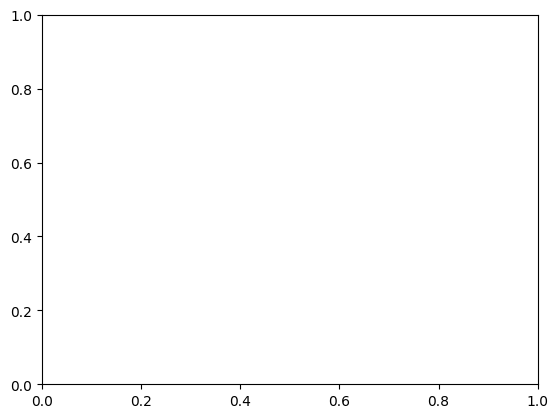

In [ ]:
# Commands to create directory and download data
!mkdir -p /content/Data
!wget -O /content/Data/german.data https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data

# --- Start of fix for FileNotFoundError in data_loader.py ---
import pandas as pd
import os
import importlib

# Path to the data_loader.py file
data_loader_module_path = '/content/SparseExplanationValues/SEV/data_loader.py'

# Read, modify, and write back the data_loader.py file to use an absolute path
with open(data_loader_module_path, 'r') as f:
    lines = f.readlines()

modified_lines = []
for line in lines:
    if 'pd.read_csv("../../Data/german.data"' in line:
        # Replace the relative path with the absolute path
        line = line.replace('../../Data/german.data', '/content/Data/german.data')
    modified_lines.append(line)

with open(data_loader_module_path, 'w') as f:
    f.writelines(modified_lines)

print("data_loader.py modified to use absolute path.")
# --- End of fix for FileNotFoundError in data_loader.py ---

from SEV.SEV import SEVPlot, SEV
from SEV import data_loader # Import the module directly

# Reload the data_loader module to pick up the changes
importlib.reload(data_loader)

from SEV.Encoder import DataEncoder
from sklearn.linear_model import LogisticRegression
import numpy as np # Import numpy

# Define a placeholder for args.dataset
class Args:
    def __init__(self):
        self.dataset = 'german'
args = Args()

# get the dataset and the negative population
X,y,X_neg = data_loader.data_loader(args.dataset) # Call the function from the reloaded module

# preprocessing the dataset
encoder = DataEncoder(standard=True)
# fit the encoder with the negative population
encoder.fit(X_neg)
# transform the whole dataset
encoded_X = encoder.transform(X)

# construction the model
lr = LogisticRegression() # Corrected typo: LogisiticRegression to LogisticRegression
lr.fit(encoded_X,y)

# for explaining the whole dataset, "plus" for SEV+, "minus" for SEV-
SEVPlot(lr,encoder, encoded_X, "plus")

# for explaning the one single instance
sev = SEV(lr,encoder,encoded_X.columns)
# get the number of sev for this instance
sev_num = sev.sev_cal(np.array(encoded_X.iloc[0]).reshape(1,-1),mode="plus")
print("The SEV Value for instance 0 is %d."%sev_num)
# get the features can be used in this explanation
features = sev.sev_count(np.array(encoded_X.iloc[0]).reshape(1,-1),mode="plus",choice=sev_num)
print("The feature used in this explanation are %s."%features)

In [ ]:
#testing stability
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from collections import Counter

# Number of bootstrap models
n_models = 30

# Store results
sev_values = []
feature_choices = []

# Choose instances to evaluate (only positives since SEV+)
model = LogisticRegression(max_iter=1000)
model.fit(encoded_X, y)
preds = model.predict(encoded_X)

positive_indices = np.where(preds == 1)[0]

# Evaluate first 50 positive instances
eval_indices = positive_indices[:50]

print(f"Evaluating {len(eval_indices)} positive instances")

# Bootstrap loop
for i in range(n_models):
    print(f"Training model {i+1}/{n_models}")

    # Bootstrap sample
    X_boot, y_boot = resample(encoded_X, y, replace=True)

    # Train logistic regression
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_boot, y_boot)

    # Initialize SEV
    sev = SEV(lr, encoder, encoded_X.columns)

    model_sev_vals = []
    model_features = []

    for idx in eval_indices:
        x_instance = np.array(encoded_X.iloc[idx]).reshape(1, -1)

        # Compute SEV value
        sev_num = sev.sev_cal(x_instance, mode="plus")
        model_sev_vals.append(sev_num)

        # Get feature set
        features = sev.sev_count(
            x_instance,
            mode="plus",
            choice=sev_num
        )

        model_features.append(tuple(sorted(features)))

    sev_values.append(model_sev_vals)
    feature_choices.append(model_features)

print("Done training all models.")

Evaluating 50 positive instances
Training model 1/30
Training model 2/30
Training model 3/30
Training model 4/30
Training model 5/30
Training model 6/30
Training model 7/30
Training model 8/30
Training model 9/30
Training model 10/30
Training model 11/30
Training model 12/30
Training model 13/30
Training model 14/30
Training model 15/30
Training model 16/30
Training model 17/30
Training model 18/30
Training model 19/30
Training model 20/30
Training model 21/30
Training model 22/30
Training model 23/30
Training model 24/30
Training model 25/30
Training model 26/30
Training model 27/30
Training model 28/30
Training model 29/30
Training model 30/30
Done training all models.


In [ ]:
sev_values = np.array(sev_values)

# SEV stability
sev_std = np.std(sev_values, axis=0)
print("Average SEV standard deviation across instances:", np.mean(sev_std))

# Feature agreement
agreement_rates = []

for instance_idx in range(len(eval_indices)):
    features_across_models = [
        feature_choices[m][instance_idx]
        for m in range(n_models)
    ]

    counts = Counter(features_across_models)
    most_common_count = counts.most_common(1)[0][1]

    agreement = most_common_count / n_models
    agreement_rates.append(agreement)

print("Average feature agreement rate:", np.mean(agreement_rates))

Average SEV standard deviation across instances: 0.050867728261325774
Average feature agreement rate: 0.18733333333333327
